In [ ]:
import pickle

# Specify the path to the pickle file you want to read
pickle_file_path = 'transaction.pkl'

# Open the pickle file in binary read mode (rb)
with open(pickle_file_path, 'rb') as file:
    # Load the data from the pickle file
    loaded_data = pickle.load(file)
# Now, the 'loaded_data' variable contains the deserialized Python object
# You can use 'loaded_data' as you would any other Python object

In [ ]:
# Filter rows where 'is_pending' is 'YANLIŞ' and 'direction' is either 'INFLOW' or 'OUTFLOW'
filtered_df = loaded_data[(loaded_data['is_deleted'] == False) & ((loaded_data['direction'] == 'INFLOW') | (loaded_data['direction'] == 'OUTFLOW'))]

# Now, 'filtered_df' contains the rows where 'is_pending' is 'YANLIŞ' and 'direction' is either 'INFLOW' or 'OUTFLOW'

In [ ]:
transactions=filtered_df

In [ ]:
import pandas as pd
# Group the DataFrame by the 'account_id' column

filtered_df['new_datetime'] = pd.to_datetime(filtered_df['date'], unit='s')
grouped_by_account = filtered_df.groupby('account_id')

# Create an empty dictionary to store the tables for each account
account_tables = {}

# Iterate over the groups (one group per unique 'account_id')
for account_id, group in grouped_by_account:
    # Within each 'account_id' group, group the data by 'datetime' and 'direction'
    # and calculate the sums of 'amount' separately for 'INFLOW' and 'OUTFLOW'
    inflow = group[group['direction'] == 'INFLOW'].groupby('new_datetime')['amount'].sum()
    outflow = group[group['direction'] == 'OUTFLOW'].groupby('new_datetime')['amount'].sum()

    # Combine the 'inflow' and 'outflow' Series into a DataFrame
    inflow_df = pd.DataFrame({'Datetime': inflow.index, 'INFLOW': inflow.values})
    outflow_df = pd.DataFrame({'Datetime': outflow.index, 'OUTFLOW': outflow.values})

    # Merge the 'inflow' and 'outflow' DataFrames on 'Datetime' column with 0 fillna
    account_table = inflow_df.merge(outflow_df, on='Datetime', how='outer').fillna(0)

    # Store the table for the current account in the dictionary
    account_tables[account_id] = account_table


<ipython-input-4-ffb9c59a72af>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['new_datetime'] = pd.to_datetime(filtered_df['date'], unit='s')


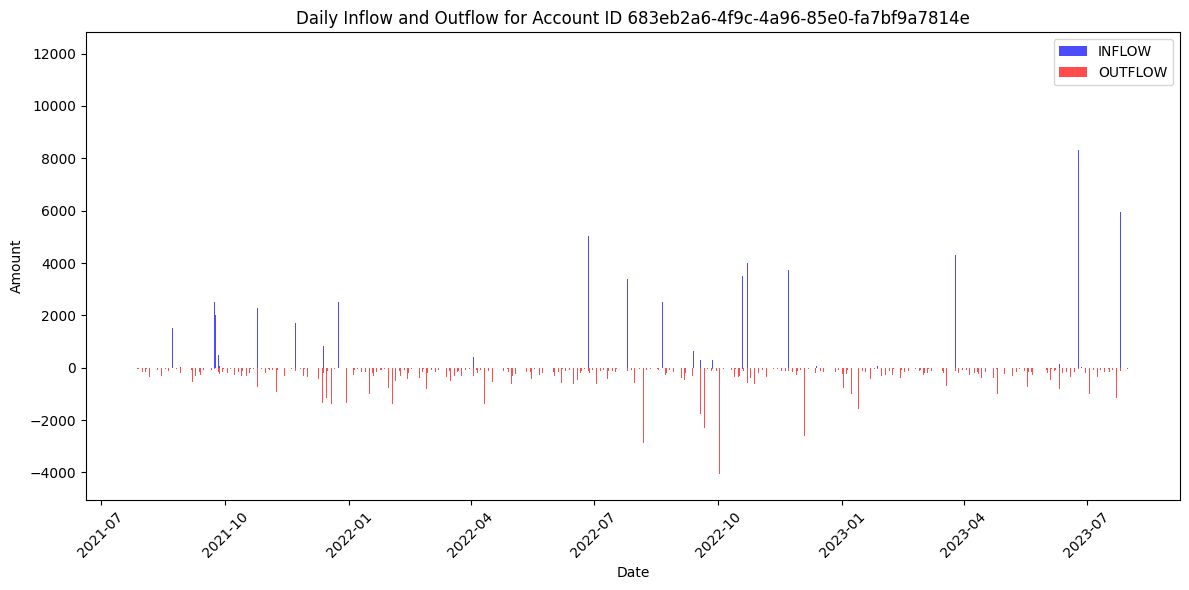

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming account_tables is a dictionary with account_id as keys and DataFrames as values
# This should be set up as described in previous conversations

# Function to generate a plot for a specific account_id
def plot_daily_inflow_outflow(account_id):
    if account_id not in account_tables:
        print(f"Account ID {account_id} not found.")
        return

    # Get the DataFrame for the specified account_id
    account_data = account_tables[account_id]

    # Plot daily inflow and outflow
    plt.figure(figsize=(12, 6))
    plt.bar(account_data['Datetime'], account_data['INFLOW'], width=0.4, label='INFLOW', color='blue', alpha=0.7)
    plt.bar(account_data['Datetime'], account_data['OUTFLOW'], width=0.4, label='OUTFLOW', color='red', alpha=0.7)
    plt.xlabel('Date')
    plt.ylabel('Amount')
    plt.title(f'Daily Inflow and Outflow for Account ID {account_id}')
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Example usage: Replace 'your_account_id' with the desired account_id
plot_daily_inflow_outflow('683eb2a6-4f9c-4a96-85e0-fa7bf9a7814e')


In [ ]:
import pandas as pd

for id, df in account_tables.items():
    # Convert 'date' to datetime if it's not already in datetime format
    df['Datetime'] = pd.to_datetime(df['Datetime'])

    # Set 'date' as index
    df.set_index('Datetime', inplace=True)

    # Resample the data to have daily frequency
    df_resampled = df.resample('D').asfreq().fillna(0)

    # Fill missing values with the last known balance (forward fill)
    df_resampled['INFLOW'].fillna(method='ffill', inplace=True)
    df_resampled['OUTFLOW'].fillna(method='ffill', inplace=True)

    # Reset index to get 'date' back as a column
    df_resampled.reset_index(inplace=True)

    # Store the modified DataFrame back in account_balances
    account_tables[id] = df_resampled

    # Print the modified DataFrame
    print(account_tables[id])

      Datetime  INFLOW  OUTFLOW
0   2021-08-02  100.00   -100.0
1   2021-08-03    0.00      0.0
2   2021-08-04    0.00      0.0
3   2021-08-05    0.00      0.0
4   2021-08-06    0.00      0.0
..         ...     ...      ...
724 2023-07-27    0.00      0.0
725 2023-07-28    0.00      0.0
726 2023-07-29    0.00      0.0
727 2023-07-30    0.00      0.0
728 2023-07-31    0.06      0.0

[729 rows x 3 columns]
      Datetime  INFLOW  OUTFLOW
0   2021-07-28  4000.0  -2000.0
1   2021-07-29     0.0  -1995.0
2   2021-07-30     0.0      0.0
3   2021-07-31     0.0      0.0
4   2021-08-01     0.0      0.0
..         ...     ...      ...
731 2023-07-29     0.0      0.0
732 2023-07-30     0.0      0.0
733 2023-07-31     0.0      0.0
734 2023-08-01     0.0      0.0
735 2023-08-02     0.0   -264.1

[736 rows x 3 columns]
      Datetime  INFLOW  OUTFLOW
0   2021-07-27  304.07  -352.40
1   2021-07-28    0.00   -32.22
2   2021-07-29    0.00   -47.75
3   2021-07-30    0.00   -49.25
4   2021-07-31    0.00  

In [ ]:
# Model training to forecast inflow outflow values
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

def perform_rolling_time_series_forecasting_sarima(account_id, account_tables):
    account_table = account_tables[account_id]

    if account_table is not None:
        account_table_copy = account_table.copy()

        if 'Datetime' in account_table_copy.columns:
            account_table_copy['Datetime'] = pd.to_datetime(account_table_copy['Datetime'])
            account_table_copy.set_index('Datetime', inplace=True)

            train_size = len(account_table_copy) -90
            train, test = account_table_copy.iloc[:train_size], account_table_copy.iloc[train_size:]
            test_ = test.copy()
            train_ = train.copy()

            prediction_df_inflow = pd.DataFrame(columns=['Predicted_INFLOW','Date'])
            prediction_df_outflow = pd.DataFrame(columns=['Predicted_OUTFLOW','Date'])

            num = 0

            while len(test) >= 30:
                num += 1

                # Forecasting INFLOW
                sarima_model_inflow = SARIMAX(train['INFLOW'], order=(2, 1, 2), seasonal_order=(1, 1, 1, 30))
                sarima_result_inflow = sarima_model_inflow.fit(disp=False)
                forecast_inflow = sarima_result_inflow.get_forecast(steps=30)
                forecast_dates_inflow = test_.index[:30]
                prediction_df_inflow = prediction_df_inflow.append(pd.DataFrame({'Predicted_INFLOW': forecast_inflow.predicted_mean.values,'Date':forecast_dates_inflow}))

                # Forecasting OUTFLOW
                sarima_model_outflow = SARIMAX(train['OUTFLOW'], order=(2, 1, 2), seasonal_order=(1, 1, 1, 30))
                sarima_result_outflow = sarima_model_outflow.fit(disp=False)
                forecast_outflow = sarima_result_outflow.get_forecast(steps=30)
                forecast_dates_outflow = test_.index[:30]
                prediction_df_outflow = prediction_df_outflow.append(pd.DataFrame({'Predicted_OUTFLOW': forecast_outflow.predicted_mean.values,'Date': forecast_dates_outflow}))

                # Updating train and test sets for the next iteration
                train = train.append(test.iloc[:30])
                test = test.iloc[30:]

            # Visualization
            end = 30 * num
            plt.figure(figsize=(12, 6))

            # Calculate MAEs
            mae_inflow = mean_absolute_error(test_['INFLOW'][:end], prediction_df_inflow['Predicted_INFLOW'])
            mae_outflow = mean_absolute_error(test_['OUTFLOW'][:end], prediction_df_outflow['Predicted_OUTFLOW'])

            print(f'Mean Absolute Error (MAE) for INFLOW: {mae_inflow:.2f}')
            print(f'Mean Absolute Error (MAE) for OUTFLOW: {mae_outflow:.2f}')

            return prediction_df_inflow, prediction_df_outflow, train_, test_, num

        else:
            print(f'No "Datetime" column found in the DataFrame.')
            return None, None

    else:
        print(f'Account ID {account_id} not found in account_tables.')
        return None, None

# Example usage
account_id = '683eb2a6-4f9c-4a96-85e0-fa7bf9a7814e'
predicted_values_inflow_df, predicted_values_outflow_df,train_, test_, num = perform_rolling_time_series_forecasting_sarima(account_id, account_tables)


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
<ipython-input-67-ec7d11d61a86>:34: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  prediction_df_inflow = prediction_df_inflow.append(pd.DataFrame({'Predicted_INFLOW': forecast_inflow.predicted_mean.values,'Date':forecast_dates_inflow}))
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_mod

Mean Absolute Error (MAE) for INFLOW: 448.61
Mean Absolute Error (MAE) for OUTFLOW: 244.70


<ipython-input-67-ec7d11d61a86>:41: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  prediction_df_outflow = prediction_df_outflow.append(pd.DataFrame({'Predicted_OUTFLOW': forecast_outflow.predicted_mean.values,'Date': forecast_dates_outflow}))
<ipython-input-67-ec7d11d61a86>:44: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  train = train.append(test.iloc[:30])


<Figure size 1200x600 with 0 Axes>

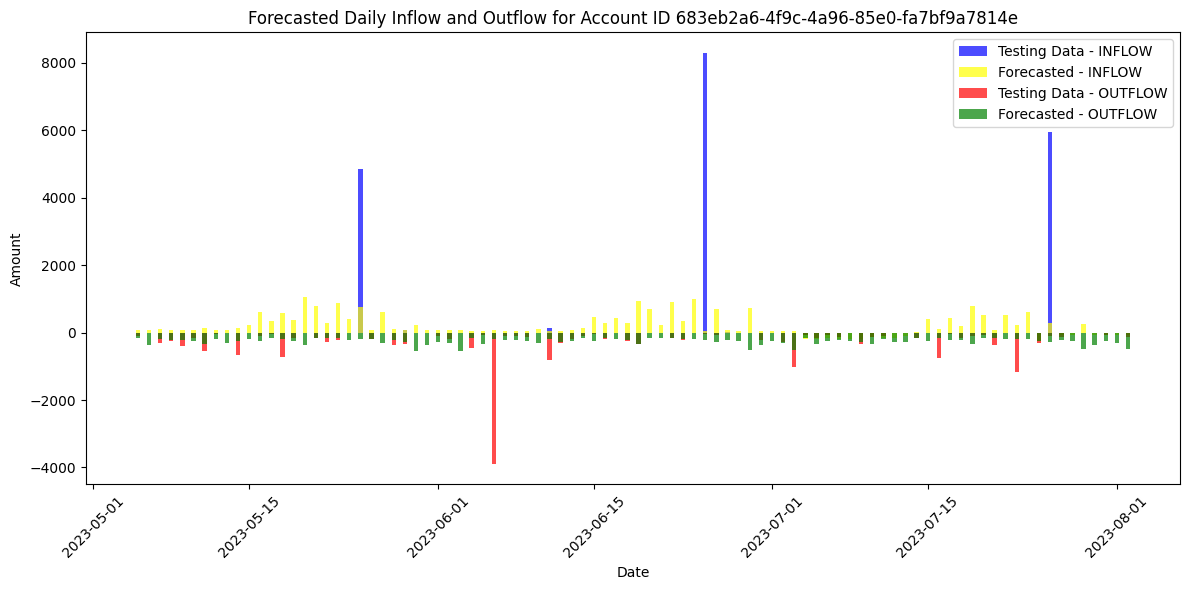

In [ ]:
def plot_forecasted_inflow_outflow(account_id, train_, test_, prediction_df_inflow, prediction_df_outflow, end):
    # Slicing last 90 values from each dataframe
    #train_display = train_.iloc[-90:]
    test_display = test_.iloc[:90]
    prediction_df_inflow_display = prediction_df_inflow.iloc[-90:]
    prediction_df_outflow_display = prediction_df_outflow.iloc[-90:]

    plt.figure(figsize=(12, 6))

    # For INFLOW
    #plt.bar(train_display.index, train_display['INFLOW'], width=0.4, label='Training Data - INFLOW', color='blue', alpha=0.7)
    plt.bar(test_display.index, test_display['INFLOW'], width=0.4, label='Testing Data - INFLOW', color='blue', alpha=0.7)
    plt.bar(test_display.index, prediction_df_inflow_display['Predicted_INFLOW'], width=0.4, label='Forecasted - INFLOW', color='yellow', alpha=0.7)

    # For OUTFLOW
    #plt.bar(train_display.index, train_display['OUTFLOW'], width=0.4, label='Training Data - OUTFLOW', color='red', alpha=0.7)
    plt.bar(test_display.index, test_display['OUTFLOW'], width=0.4, label='Testing Data - OUTFLOW', color='red', alpha=0.7)
    plt.bar(test_display.index, prediction_df_outflow_display['Predicted_OUTFLOW'], width=0.4, label='Forecasted - OUTFLOW', color='green', alpha=0.7)

    plt.xlabel('Date')
    plt.ylabel('Amount')
    plt.title(f'Forecasted Daily Inflow and Outflow for Account ID {account_id}')
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
plot_forecasted_inflow_outflow(account_id, train_, test_, predicted_values_inflow_df, predicted_values_outflow_df, num*30)


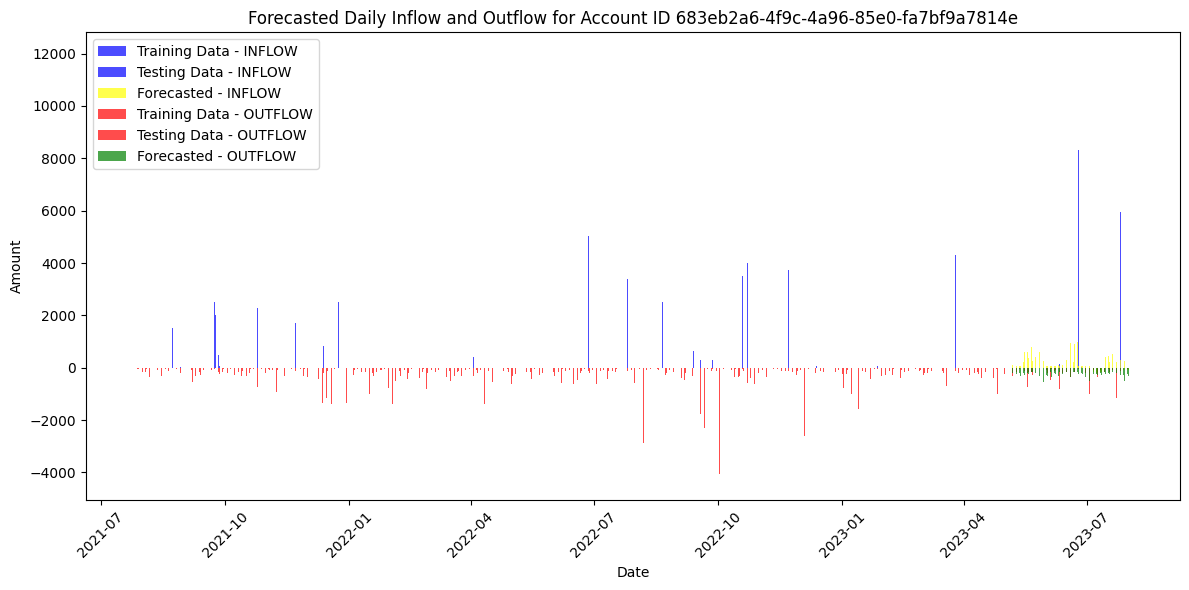

In [ ]:
def plot_forecasted_inflow_outflow(account_id, train_, test_, prediction_df_inflow, prediction_df_outflow, end):
    plt.figure(figsize=(12, 6))

    # For INFLOW
    # Blue bars for Training Data
    plt.bar(train_.index, train_['INFLOW'], width=0.4, label='Training Data - INFLOW', color='blue', alpha=0.7)
    # Light blue bars for Testing Data
    plt.bar(test_.index[:end], test_['INFLOW'][:end], width=0.4, label='Testing Data - INFLOW', color='blue', alpha=0.7)
    # Blue stripes for Forecasted Data
    plt.bar(test_.index[:end], prediction_df_inflow['Predicted_INFLOW'], width=0.4, label='Forecasted - INFLOW', color='yellow', alpha=0.7)

    # For OUTFLOW
    # Red bars for Training Data
    plt.bar(train_.index, train_['OUTFLOW'], width=0.4, label='Training Data - OUTFLOW', color='red', alpha=0.7)
    # Pink bars for Testing Data
    plt.bar(test_.index[:end], test_['OUTFLOW'][:end], width=0.4, label='Testing Data - OUTFLOW', color='red', alpha=0.7)
    # Red stripes for Forecasted Data
    plt.bar(test_.index[:end], prediction_df_outflow['Predicted_OUTFLOW'], width=0.4, label='Forecasted - OUTFLOW', color='green', alpha=0.7)

    plt.xlabel('Date')
    plt.ylabel('Amount')
    plt.title(f'Forecasted Daily Inflow and Outflow for Account ID {account_id}')
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Use the function like:
plot_forecasted_inflow_outflow(account_id, train_, test_, predicted_values_inflow_df, predicted_values_outflow_df, num*30)


In [ ]:
predicted_values_outflow_df['Date']=test_.index
predicted_values_inflow_df['Date']=test_.index
predicted_values_inflow_df


,Predicted_INFLOW,Date
0,77.105087,2023-05-05
1,72.075401,2023-05-06
2,104.935163,2023-05-07
3,72.295968,2023-05-08
4,72.692939,2023-05-09
...,...,...
25,242.472464,2023-07-29
26,-75.384050,2023-07-30
27,-72.366201,2023-07-31
28,-68.459017,2023-08-01


In [ ]:
import pickle
# Specify the path to the pickle file you want to read
pickle_file_path_2 = 'account.pkl'

# Open the pickle file in binary read mode (rb)
with open(pickle_file_path_2, 'rb') as file:
    # Load the data from the pickle file
    loaded_data_2 = pickle.load(file)

In [ ]:
#In order to form the account balance tables
account_balances = {}  # Create an empty dictionary
grouped_by_account_2 = loaded_data_2.groupby('id')

# Assuming account_tables is a dictionary with account_id as keys and DataFrames as values
for id, group in grouped_by_account_2:
    if id in account_tables:
        account_table = account_tables[id]  # Get the corresponding account table
        filtered_2 = loaded_data_2[loaded_data_2['id'] == id]  # Filter loaded_data_2 for the specific account_id
        if filtered_2['type'].iloc[0] == 'DEPOSIT':
          final_balance = filtered_2['balance_available_amount'].iloc[0]
          final_date = pd.to_datetime(filtered_2['external_last_updated_datetime'].iloc[0]).date()

          date_range = pd.date_range(start=account_table['Datetime'].min(), end=final_date)
          account_balance = pd.DataFrame({'date': [final_date], 'balance': final_balance})

          current_balance = final_balance

          table_sorted_reverse = account_table.sort_values(by='Datetime', ascending=False)

          for index, row in table_sorted_reverse.iterrows():
              inflow = row['INFLOW']
              outflow = row['OUTFLOW']
              date_ = row['Datetime']
              current_balance = current_balance - inflow + outflow
              new_row = {'date': date_, 'balance': current_balance}
              account_balance = account_balance.append(new_row, ignore_index=True)
        elif filtered_2['type'].iloc[0] == 'CREDIT':
            final_balance = filtered_2['balance_current_amount'].iloc[0]
            final_date = pd.to_datetime(filtered_2['external_last_updated_datetime'].iloc[0]).date()

            date_range = pd.date_range(start=account_table['Datetime'].min(), end=final_date)
            account_balance = pd.DataFrame({'date': [final_date], 'balance': final_balance})

            current_balance = final_balance

            table_sorted_reverse = account_table.sort_values(by='Datetime', ascending=False)

            for index, row in table_sorted_reverse.iterrows():
                inflow = row['INFLOW']
                outflow = row['OUTFLOW']
                date_ = row['Datetime']
                current_balance = current_balance + inflow - outflow
                new_row = {'date': date_, 'balance': current_balance}
                account_balance = account_balance.append(new_row, ignore_index=True)

        account_balance = account_balance.sort_values(by='date', ascending=True)
        account_balances[id] = account_balance

# Now, account_balances contains a dictionary where each account ID is associated with a DataFrame containing final_balance and historical_balances


Görüntülenen çıkış son 5000 satıra kısaltıldı.
<ipython-input-22-f73dfe912eb3>:44: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance = account_balance.append(new_row, ignore_index=True)
<ipython-input-22-f73dfe912eb3>:44: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance = account_balance.append(new_row, ignore_index=True)
<ipython-input-22-f73dfe912eb3>:44: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance = account_balance.append(new_row, ignore_index=True)
<ipython-input-22-f73dfe912eb3>:44: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  account_balance = account_balance.append(new_row, ignore_index

In [ ]:
import pandas as pd

# Assuming you have a dictionary called account_balances

for id, df in account_balances.items():
    print(id)
    # Convert 'date' to datetime if it's not already in datetime format
    df['date'] = pd.to_datetime(df['date'])

    # Set 'date' as index
    df.set_index('date', inplace=True)

    # Resample the data to have daily frequency
    df_resampled = df.resample('D').last()

    # Fill missing values with the last known balance (forward fill)
    df_resampled['balance'].fillna(method='ffill', inplace=True)

    # Reset index to get 'date' back as a column
    df_resampled.reset_index(inplace=True)

    # Store the modified DataFrame back in account_balances
    account_balances[id] = df_resampled

    # Print the modified DataFrame
    print(df_resampled)


4c01f230-75ab-4cb8-b83d-8a9214795d40
          date  balance
0   2021-08-02  -899.61
1   2021-08-03  -699.61
2   2021-08-04  -699.61
3   2021-08-05  -699.61
4   2021-08-06  -699.61
..         ...      ...
727 2023-07-30   500.51
728 2023-07-31   500.51
729 2023-08-01   500.51
730 2023-08-02   500.51
731 2023-08-03   500.57

[732 rows x 2 columns]
5332798b-523f-4d9a-9c7d-38f5aedfad60
          date    balance
0   2021-07-28 -589904.42
1   2021-07-29 -583904.42
2   2021-07-30 -581909.42
3   2021-07-31 -581909.42
4   2021-08-01 -581909.42
..         ...        ...
731 2023-07-29    3195.00
732 2023-07-30    3195.00
733 2023-07-31    3195.00
734 2023-08-01    3195.00
735 2023-08-02    3459.10

[736 rows x 2 columns]
683eb2a6-4f9c-4a96-85e0-fa7bf9a7814e
          date    balance
0   2021-07-27  310003.97
1   2021-07-28  309347.50
2   2021-07-29  309315.28
3   2021-07-30  309267.53
4   2021-07-31  309218.28
..         ...        ...
732 2023-07-29     265.50
733 2023-07-30     265.50
734 202

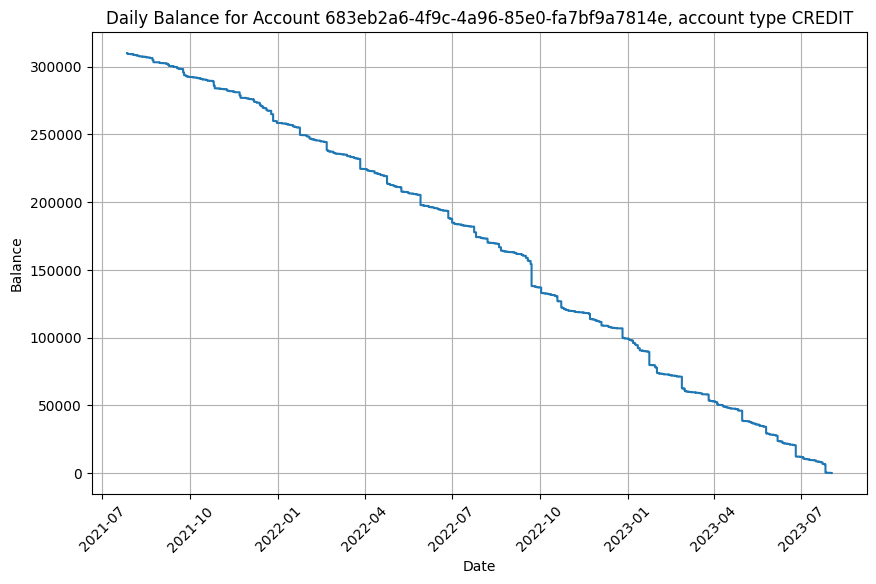

In [ ]:
import matplotlib.pyplot as plt

# Assuming you have account_balances available

def plot_daily_balance(account_id):
    account_balance = account_balances.get(account_id)

    if account_balance is not None:
        account_type = loaded_data_2[loaded_data_2['id'] == account_id]['type'].iloc[0]
        plt.figure(figsize=(10, 6))
        plt.step(account_balance['date'], account_balance['balance'], where='mid')
        plt.title(f'Daily Balance for Account {account_id}, account type {account_type}')
        plt.xlabel('Date')
        plt.ylabel('Balance')
        plt.xticks(rotation=45)
        plt.grid(True)
        plt.show()
    else:
        print(f'Account ID {account_id} not found in account_balances.')

# Example usage:
plot_daily_balance('683eb2a6-4f9c-4a96-85e0-fa7bf9a7814e')

In [ ]:
# Creating balance graphs from the predicted inflow outflow values

# Write the account name desired
choosen_account_id='683eb2a6-4f9c-4a96-85e0-fa7bf9a7814e'
filtered_2 = loaded_data_2[loaded_data_2['id'] == choosen_account_id]
ending=round((account_balances[choosen_account_id]['balance'].size)*(0.2))+2
if filtered_2['type'].iloc[0] == 'DEPOSIT':
  final_balance = account_balances[choosen_account_id]['balance'].iloc[-ending]
  #final_date = pd.to_datetime(filtered_2['external_last_updated_datetime'].iloc[0]).date()
  final_date=account_balances[choosen_account_id]['date'].iloc[-ending]
  #date_range = pd.date_range(start=account_table_balance['Date'].min(), end=final_date)
  #account_table_balance = pd.DataFrame({'date': [final_date], 'balance': final_balance})

  # Initializing an empty dataframe with columns 'date' and 'balance'
  account_table_balance = pd.DataFrame(columns=['date', 'balance'])

  # Using .loc to add a new row
  account_table_balance.loc[0] = [final_date, final_balance]
  current_balance = final_balance

  #table_sorted_reverse_inflow = predicted_values_inflow_df.sort_values(by='Date', ascending=False)
  #table_sorted_reverse_outflow = predicted_values_outflow_df.sort_values(by='Date', ascending=False)
  #combined = pd.merge(table_sorted_reverse_inflow, table_sorted_reverse_outflow, on='Date', how='inner')
  predicted_values = pd.DataFrame()
  predicted_values_inflow_df = predicted_values_inflow_df[['Date', 'Predicted_INFLOW']]
  predicted_values[['Date', 'Predicted_INFLOW']]=predicted_values_inflow_df[['Date', 'Predicted_INFLOW']]
  predicted_values['Predicted_OUTFLOW'] = predicted_values_outflow_df['Predicted_OUTFLOW']
  predicted_values['NET_INCOME']=predicted_values['Predicted_INFLOW']-predicted_values['Predicted_OUTFLOW']
  predicted_values.drop(columns=['Predicted_INFLOW'], inplace=True)
  predicted_values.drop(columns=['Predicted_OUTFLOW'], inplace=True)

  for index, row in predicted_values.iterrows():
      net_income = row['NET_INCOME']
      date_ = row['Date']

      # Adjust the current_balance based on net_income
      current_balance += net_income

      # Append the updated balance for the date_ to account_table_balance
      account_table_balance.loc[len(account_table_balance)] = [date_, current_balance]

elif filtered_2['type'].iloc[0] == 'CREDIT':
    final_balance = account_balances[choosen_account_id]['balance'].iloc[-ending]
    final_date=account_balances[choosen_account_id]['date'].iloc[-ending]

    #date_range = pd.date_range(start=predicted_values_inflow_df['Date'].min(), end=final_date)
    #account_table_balance = pd.DataFrame({'date': [final_date], 'balance': final_balance})
    # Initializing an empty dataframe with columns 'date' and 'balance'
    account_table_balance = pd.DataFrame(columns=['date', 'balance'])

    # Using .loc to add a new row
    account_table_balance.loc[0] = [final_date, final_balance]

    current_balance = final_balance

    predicted_values = pd.DataFrame()
    predicted_values_inflow_df = predicted_values_inflow_df[['Date', 'Predicted_INFLOW']]
    predicted_values[['Date', 'Predicted_INFLOW']]=predicted_values_inflow_df[['Date', 'Predicted_INFLOW']]
    predicted_values['Predicted_OUTFLOW'] = predicted_values_outflow_df['Predicted_OUTFLOW']
    predicted_values['NET_INCOME']=-predicted_values['Predicted_INFLOW']+predicted_values['Predicted_OUTFLOW']
    predicted_values.drop(columns=['Predicted_INFLOW'], inplace=True)
    predicted_values.drop(columns=['Predicted_OUTFLOW'], inplace=True)
    #predicted_values = predicted_values.sort_values(by='Date')

    for index, row in predicted_values.iterrows():
        net_income = row['NET_INCOME']
        date_ = row['Date']

        # Adjust the current_balance based on net_income
        current_balance += net_income

        # Append the updated balance for the date_ to account_table_balance
        account_table_balance.loc[len(account_table_balance)] = [date_, current_balance]



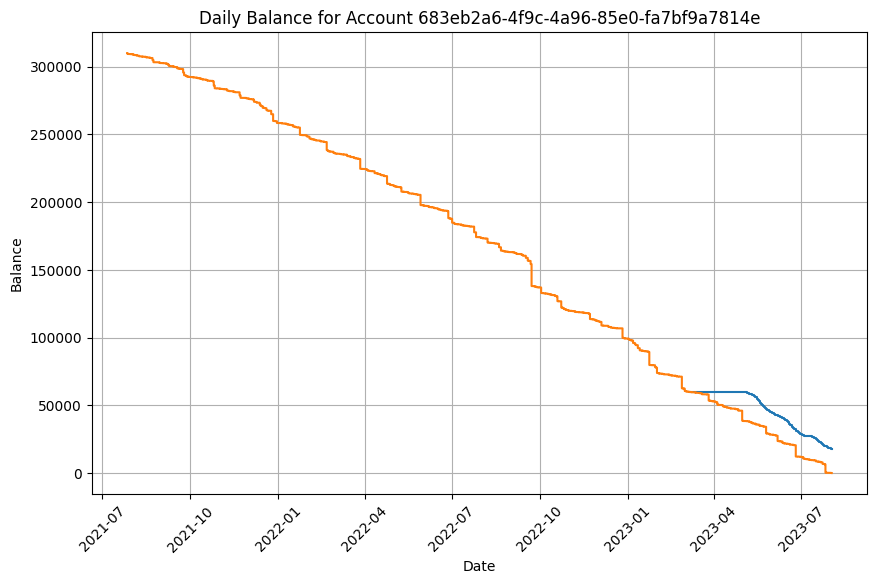

In [ ]:
#account_type = loaded_data_2[loaded_data_2['id'] == account_id]['type'].iloc[0]
plt.figure(figsize=(10, 6))
plt.step(account_table_balance['date'], account_table_balance['balance'], where='mid')
plt.step(account_balances[choosen_account_id]['date'], account_balances[choosen_account_id]['balance'], where='mid')
plt.title(f'Daily Balance for Account {account_id}')
plt.xlabel('Date')
plt.ylabel('Balance')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

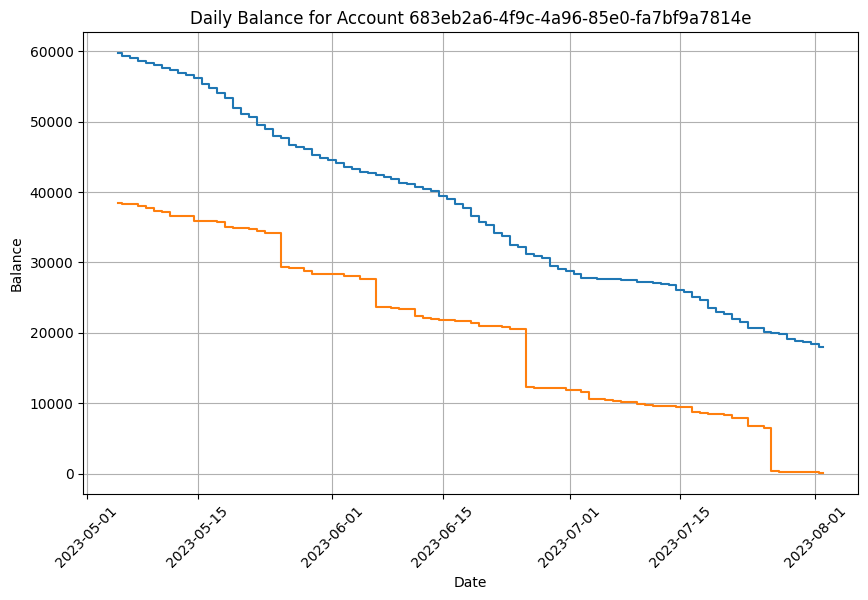

In [ ]:
#account_type = loaded_data_2[loaded_data_2['id'] == account_id]['type'].iloc[0]
plt.figure(figsize=(10, 6))
plt.step(account_table_balance['date'][-90:], account_table_balance['balance'][-90:], where='mid')
plt.step(account_balances[choosen_account_id]['date'][-90:], account_balances[choosen_account_id]['balance'][-90:], where='mid')
plt.title(f'Daily Balance for Account {account_id}')
plt.xlabel('Date')
plt.ylabel('Balance')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()